In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import sys

sys.path.append(str(Path("..").resolve()))

from src.config import RAW_DATA_PATH

# Папка для рисунков главы 2
FIG_DIR = Path("../figures/chapter2")
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Загрузка и базовая очистка, как в 02_preprocessing_and_target.ipynb
df = pd.read_csv(RAW_DATA_PATH)

df["calendar_date"] = pd.to_datetime(df["calendar_date"], errors="coerce")
df = df.dropna(subset=["SEQN", "calendar_date", "sleep_efficiency"])
df = df.sort_values(["SEQN", "calendar_date"]).reset_index(drop=True)

print("Размер массива:", df.shape)
df.head()

Размер массива: (89104, 42)


,SEQN,weekday,dayofweek,calendar_date,guider,window_number,night_number,nonwear_perc_day,nonwear_perc_spt,nonwear_perc_day_spt,...,dur_spt_wake_MOD_min,dur_spt_wake_VIG_min,dur_day_min,dur_spt_min,dur_day_spt_min,ACC_spt_sleep_mg,excluded,mec4yr,SDMVPSU,SDMVSTRA
0,62161,Sunday,1,2000-01-09,HDCZA,1,2,0.0,0.0,0.0,...,0,0,876,477,1353,6.743,0,52118.291277,1,91
1,62161,Monday,2,2000-01-10,HDCZA,2,3,0.0,0.0,0.0,...,0,0,942,496,1438,3.550,0,52118.291277,1,91
2,62161,Tuesday,3,2000-01-11,HDCZA,3,4,0.0,0.0,0.0,...,0,0,896,546,1442,3.243,0,52118.291277,1,91
3,62161,Wednesday,4,2000-01-12,HDCZA,4,5,0.0,0.0,0.0,...,0,0,902,538,1440,5.848,0,52118.291277,1,91
4,62161,Thursday,5,2000-01-13,HDCZA,5,6,0.0,0.0,0.0,...,0,0,966,599,1565,8.036,0,52118.291277,1,91


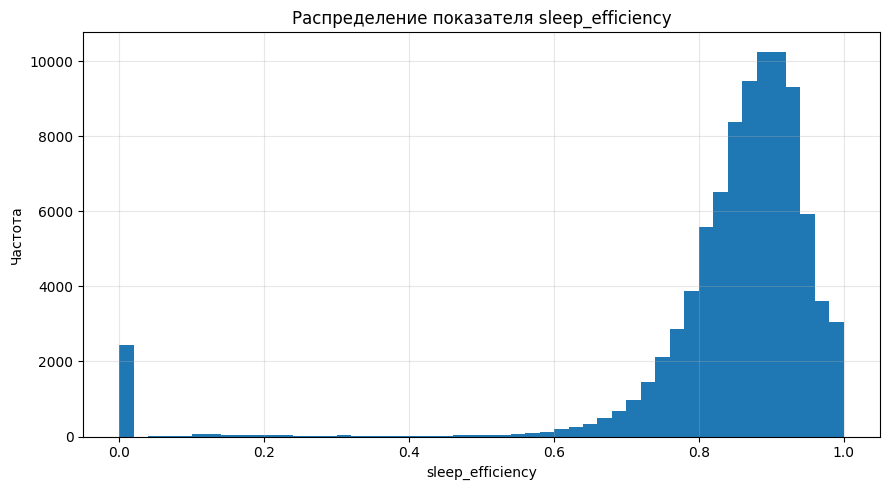

In [29]:
plt.figure(figsize=(9, 5))
plt.hist(df["sleep_efficiency"], bins=50)
plt.title("Распределение показателя sleep_efficiency")
plt.xlabel("sleep_efficiency")
plt.ylabel("Частота")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / "figure_2_1_sleep_efficiency_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

In [30]:
threshold = 0.85

df["target_bad_sleep"] = (df["sleep_efficiency"] < threshold).astype("int8")

print("Порог theta =", threshold)
print(df["target_bad_sleep"].value_counts())
print(df["target_bad_sleep"].value_counts(normalize=True))

Порог theta = 0.85
target_bad_sleep
0    56211
1    32893
Name: count, dtype: int64
target_bad_sleep
0    0.630847
1    0.369153
Name: proportion, dtype: float64


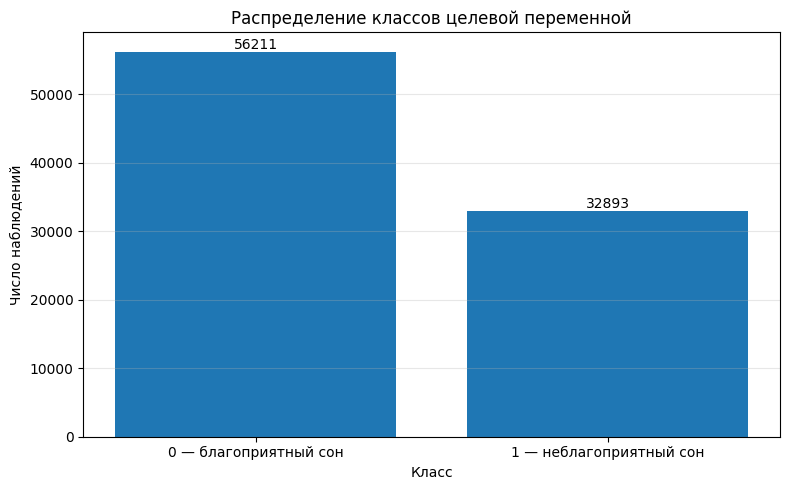

In [31]:
class_counts = df["target_bad_sleep"].value_counts().sort_index()
class_labels = ["0 — благоприятный сон", "1 — неблагоприятный сон"]

plt.figure(figsize=(8, 5))
plt.bar(class_labels, class_counts.values)
plt.title(f"Распределение классов целевой переменной")
plt.xlabel("Класс")
plt.ylabel("Число наблюдений")
plt.grid(axis="y", alpha=0.3)

for i, v in enumerate(class_counts.values):
    plt.text(i, v, str(v), ha="center", va="bottom")

plt.tight_layout()
plt.savefig(FIG_DIR / "figure_2_2_target_class_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import sys

from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import (
    roc_curve,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression

from catboost import CatBoostClassifier, Pool

In [33]:
sys.path.append(str(Path("..").resolve()))

from src.config import MODEL_DATA_PATH, RANDOM_STATE

FIG_DIR = Path("../figures/chapter3")
FIG_DIR.mkdir(parents=True, exist_ok=True)

MODELS_DIR = Path("../models/catboost")  # если делаешь в этом окружении


In [34]:
model_df = pd.read_csv(MODEL_DATA_PATH)

print(model_df.shape)
print(model_df["target_bad_sleep"].value_counts(normalize=True))
model_df.head()

(47523, 82)
target_bad_sleep
0    0.627928
1    0.372072
Name: proportion, dtype: float64


,SEQN,calendar_date,weekday,dayofweek,window_number,night_number,month,day,dayofyear,target_bad_sleep,...,dur_spt_sleep_min_lag3,dur_spt_wake_IN_min_lag3,dur_spt_wake_LIG_min_lag3,dur_spt_wake_MOD_min_lag3,dur_spt_wake_VIG_min_lag3,dur_day_min_lag3,dur_spt_min_lag3,dur_day_spt_min_lag3,ACC_spt_sleep_mg_lag3,excluded_lag3
0,62161,2000-01-12,Wednesday,4,4,5,1,12,12,1,...,436.0,39.0,2.0,0.0,0.0,876.0,477.0,1353.0,6.743,0.0
1,62161,2000-01-13,Thursday,5,5,6,1,13,13,1,...,403.0,92.0,1.0,0.0,0.0,942.0,496.0,1438.0,3.550,0.0
2,62161,2000-01-14,Friday,6,6,7,1,14,14,1,...,435.0,101.0,10.0,0.0,0.0,896.0,546.0,1442.0,3.243,0.0
3,62161,2000-01-15,Saturday,7,7,8,1,15,15,1,...,425.0,108.0,5.0,0.0,0.0,902.0,538.0,1440.0,5.848,0.0
4,62163,2000-01-12,Wednesday,4,4,5,1,12,12,0,...,332.0,43.0,3.0,0.0,0.0,1004.0,378.0,1382.0,11.669,0.0


In [35]:
target_col = "target_bad_sleep"
group_col = "SEQN"

X = model_df.drop(columns=[target_col]).copy()
y = model_df[target_col].astype(int).copy()
groups = model_df[group_col].copy()

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train_full = X.iloc[train_idx].copy()
X_test_full = X.iloc[test_idx].copy()

y_train = y.iloc[train_idx].copy()
y_test = y.iloc[test_idx].copy()

groups_train = groups.iloc[train_idx]
groups_test = groups.iloc[test_idx]

print("Train:", X_train_full.shape, y_train.shape)
print("Test :", X_test_full.shape, y_test.shape)
print("Train users:", groups_train.nunique())
print("Test users :", groups_test.nunique())
print("Intersection:", len(set(groups_train).intersection(set(groups_test))))

Train: (37976, 81) (37976,)
Test : (9547, 81) (9547,)
Train users: 10430
Test users : 2608
Intersection: 0


In [36]:
def select_feature_set(X: pd.DataFrame, feature_mode: str = "full") -> pd.DataFrame:
    X = X.copy()

    if feature_mode == "full":
        drop_cols = ["SEQN", "calendar_date"]
        return X.drop(columns=[c for c in drop_cols if c in X.columns])

    if feature_mode == "no_sleep_quality_lag":
        drop_cols = [
            "SEQN",
            "calendar_date",
            "sleep_efficiency_lag1",
            "sleep_efficiency_lag2",
            "sleep_efficiency_lag3",
        ]
        return X.drop(columns=[c for c in drop_cols if c in X.columns])

    if feature_mode == "activity_only":
        drop_cols = [
            "SEQN", "calendar_date",
            "sleep_efficiency_lag1", "sleep_efficiency_lag2", "sleep_efficiency_lag3",
            "dur_spt_sleep_min_lag1", "dur_spt_sleep_min_lag2", "dur_spt_sleep_min_lag3",
            "dur_spt_wake_IN_min_lag1", "dur_spt_wake_IN_min_lag2", "dur_spt_wake_IN_min_lag3",
            "dur_spt_wake_LIG_min_lag1", "dur_spt_wake_LIG_min_lag2", "dur_spt_wake_LIG_min_lag3",
            "dur_spt_wake_MOD_min_lag1", "dur_spt_wake_MOD_min_lag2", "dur_spt_wake_MOD_min_lag3",
            "dur_spt_wake_VIG_min_lag1", "dur_spt_wake_VIG_min_lag2", "dur_spt_wake_VIG_min_lag3",
            "dur_spt_min_lag1", "dur_spt_min_lag2", "dur_spt_min_lag3",
            "sleeponset_lag1", "sleeponset_lag2", "sleeponset_lag3",
            "wakeup_lag1", "wakeup_lag2", "wakeup_lag3"
        ]
        return X.drop(columns=[c for c in drop_cols if c in X.columns])

    raise ValueError(f"Unknown feature_mode: {feature_mode}")

In [37]:
X_train_baseline = select_feature_set(X_train_full, "full")
X_test_baseline = select_feature_set(X_test_full, "full")

categorical_cols = X_train_baseline.select_dtypes(include=["object"]).columns.tolist()
numeric_cols = [c for c in X_train_baseline.columns if c not in categorical_cols]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]),
            numeric_cols
        ),
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore"))
            ]),
            categorical_cols
        ),
    ]
)

baseline_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ))
])

baseline_model.fit(X_train_baseline, y_train)

baseline_proba = baseline_model.predict_proba(X_test_baseline)[:, 1]
baseline_pred = (baseline_proba >= 0.5).astype(int)

baseline_auc = roc_auc_score(y_test, baseline_proba)
baseline_precision = precision_score(y_test, baseline_pred, zero_division=0)
baseline_recall = recall_score(y_test, baseline_pred, zero_division=0)
baseline_f1 = f1_score(y_test, baseline_pred, zero_division=0)

print("Baseline ROC-AUC :", round(baseline_auc, 4))
print("Baseline Precision:", round(baseline_precision, 4))
print("Baseline Recall   :", round(baseline_recall, 4))
print("Baseline F1       :", round(baseline_f1, 4))

Baseline ROC-AUC : 0.7408
Baseline Precision: 0.5727
Baseline Recall   : 0.6264
Baseline F1       : 0.5984


In [38]:
model_specs = [
    {
        "name": "CatBoost full",
        "file": MODELS_DIR / "catboost_full.cbm",
        "mode": "full",
        "threshold": 0.30
    },
    {
        "name": "CatBoost no_sleep_quality_lag",
        "file": MODELS_DIR / "catboost_no_sleep_quality_lag.cbm",
        "mode": "no_sleep_quality_lag",
        "threshold": 0.30
    },
    {
        "name": "CatBoost tuned_no_sleep_quality_lag",
        "file": MODELS_DIR / "catboost_tuned_no_sleep_quality_lag.cbm",
        "mode": "no_sleep_quality_lag",
        "threshold": 0.30
    },
    {
        "name": "CatBoost activity_only",
        "file": MODELS_DIR / "catboost_activity_only.cbm",
        "mode": "activity_only",
        "threshold": 0.30
    },
]

results = []

for spec in model_specs:
    X_test_model = select_feature_set(X_test_full, spec["mode"]).copy()

    categorical_cols = X_test_model.select_dtypes(include=["object"]).columns.tolist()
    cat_features = [X_test_model.columns.get_loc(col) for col in categorical_cols]

    test_pool = Pool(X_test_model, y_test, cat_features=cat_features)

    model = CatBoostClassifier()
    model.load_model(str(spec["file"]))

    y_proba = model.predict_proba(test_pool)[:, 1]
    y_pred = (y_proba >= spec["threshold"]).astype(int)

    auc = roc_auc_score(y_test, y_proba)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    fpr, tpr, _ = roc_curve(y_test, y_proba)

    results.append({
        "name": spec["name"],
        "mode": spec["mode"],
        "threshold": spec["threshold"],
        "auc": auc,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "fpr": fpr,
        "tpr": tpr
    })

    print(
        spec["name"],
        "| ROC-AUC =", round(auc, 4),
        "| Precision =", round(precision, 4),
        "| Recall =", round(recall, 4),
        "| F1 =", round(f1, 4)
    )

    print(spec["name"], "ROC-AUC =", round(auc, 4), "| F1 =", round(f1, 4))

CatBoost full | ROC-AUC = 0.7461 | Precision = 0.5144 | Recall = 0.764 | F1 = 0.6149
CatBoost full ROC-AUC = 0.7461 | F1 = 0.6149
CatBoost no_sleep_quality_lag | ROC-AUC = 0.7464 | Precision = 0.5105 | Recall = 0.776 | F1 = 0.6159
CatBoost no_sleep_quality_lag ROC-AUC = 0.7464 | F1 = 0.6159
CatBoost tuned_no_sleep_quality_lag | ROC-AUC = 0.7454 | Precision = 0.5081 | Recall = 0.7706 | F1 = 0.6124
CatBoost tuned_no_sleep_quality_lag ROC-AUC = 0.7454 | F1 = 0.6124
CatBoost activity_only | ROC-AUC = 0.6004 | Precision = 0.3968 | Recall = 0.8521 | F1 = 0.5414
CatBoost activity_only ROC-AUC = 0.6004 | F1 = 0.5414


In [39]:
results_for_table = [
    {
        "name": "Baseline (LogReg)",
        "auc": baseline_auc,
        "precision": baseline_precision,
        "recall": baseline_recall,
        "f1": baseline_f1
    }
]

for r in results:
    results_for_table.append({
        "name": r["name"],
        "auc": r["auc"],
        "precision": r["precision"],
        "recall": r["recall"],
        "f1": r["f1"]
    })

results_df = pd.DataFrame(results_for_table)

results_df["short_name"] = [
    "Baseline",
    "Full",
    "No sleep\nquality lag",
    "Tuned no sleep\nquality lag",
    "Activity\nonly"
]

results_df.round(4)

,name,auc,precision,recall,f1,short_name
0,Baseline (LogReg),0.7408,0.5727,0.6264,0.5984,Baseline
1,CatBoost full,0.7461,0.5144,0.7640,0.6149,Full
2,CatBoost no_sleep_quality_lag,0.7464,0.5105,0.7760,0.6159,No sleep\nquality lag
3,CatBoost tuned_no_sleep_quality_lag,0.7454,0.5081,0.7706,0.6124,Tuned no sleep\nquality lag
4,CatBoost activity_only,0.6004,0.3968,0.8521,0.5414,Activity\nonly


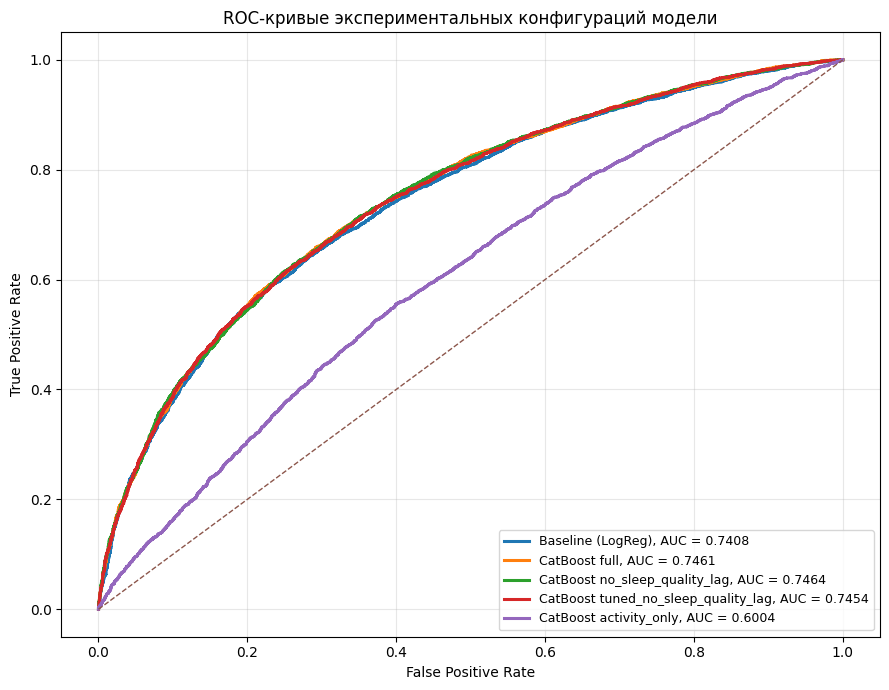

In [40]:
plt.figure(figsize=(9, 7))

# baseline
fpr_base, tpr_base, _ = roc_curve(y_test, baseline_proba)
plt.plot(
    fpr_base, tpr_base,
    linewidth=2.2,
    label=f"Baseline (LogReg), AUC = {baseline_auc:.4f}"
)

# catboost models
for r in results:
    plt.plot(
        r["fpr"], r["tpr"],
        linewidth=2.2,
        label=f'{r["name"]}, AUC = {r["auc"]:.4f}'
    )

# diagonal
plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1)

plt.title("ROC-кривые экспериментальных конфигураций модели")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right", fontsize=9)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / "figure_3_4_roc_curves.png", dpi=300, bbox_inches="tight")
plt.show()

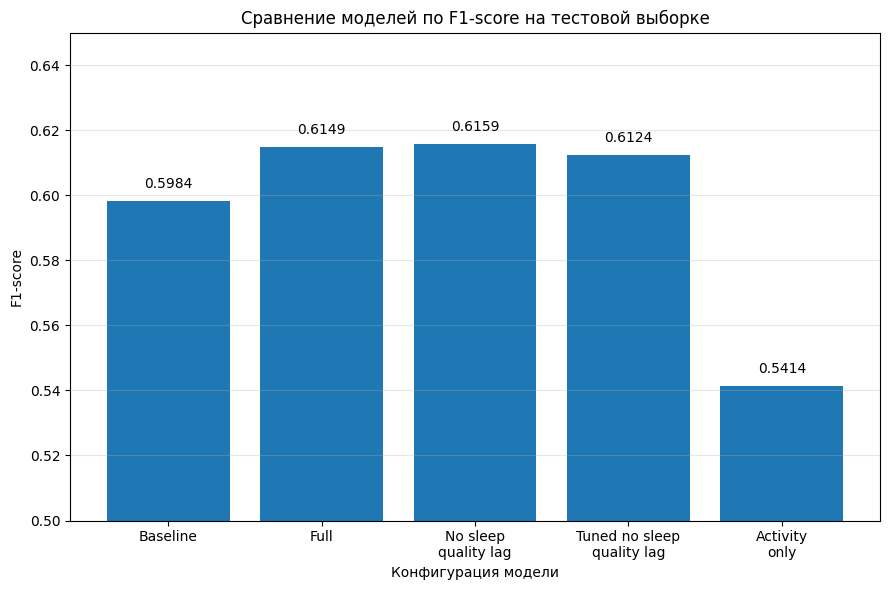

In [41]:
plot_df = results_df.copy()

plot_df["short_name"] = [
    "Baseline",
    "Full",
    "No sleep\nquality lag",
    "Tuned no sleep\nquality lag",
    "Activity\nonly"
]

plt.figure(figsize=(9, 6))
bars = plt.bar(plot_df["short_name"], plot_df["f1"])

plt.title("Сравнение моделей по F1-score на тестовой выборке")
plt.xlabel("Конфигурация модели")
plt.ylabel("F1-score")
plt.ylim(0.50, 0.65)
plt.grid(axis="y", alpha=0.3)

for bar, value in zip(bars, plot_df["f1"]):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        value + 0.003,
        f"{value:.4f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.savefig(FIG_DIR / "figure_3_5_f1_scores.png", dpi=300, bbox_inches="tight")
plt.show()

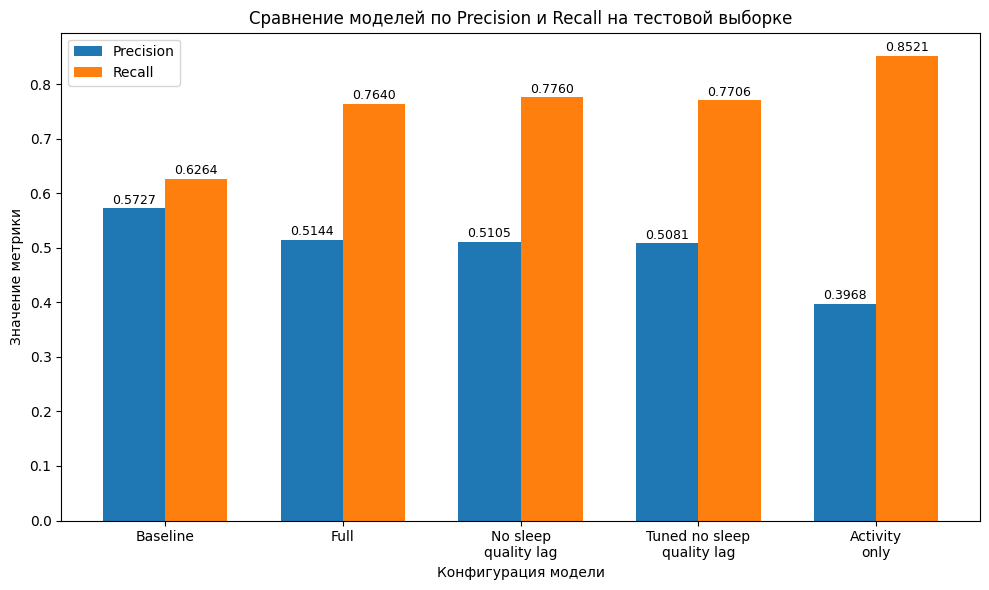

In [ ]:
plot_df = results_df.copy()

x = np.arange(len(plot_df))
width = 0.35

plt.figure(figsize=(10, 6))

bars_precision = plt.bar(
    x - width / 2,
    plot_df["precision"],
    width,
    label="Precision"
)

bars_recall = plt.bar(
    x + width / 2,
    plot_df["recall"],
    width,
    label="Recall"
)

plt.title("Сравнение моделей по Precision и Recall на тестовой выборке")
plt.xlabel("Конфигурация модели")
plt.ylabel("Значение метрики")
plt.xticks(x, plot_df["short_name"])
# plt.ylim(0.45, 0.75)
# plt.grid(axis="y", alpha=0.3)
plt.legend()

for bars in [bars_precision, bars_recall]:
    for bar in bars:
        value = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            value + 0.003,
            f"{value:.4f}",
            ha="center",
            va="bottom",
            fontsize=9
        )

plt.tight_layout()
plt.savefig(
    FIG_DIR / "figure_3_5_precision_recall_comparison.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [43]:
from catboost import CatBoostClassifier, Pool
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

final_model_path = MODELS_DIR / "catboost_tuned_no_sleep_quality_lag.cbm"

X_test_final_model = select_feature_set(X_test_full, "no_sleep_quality_lag").copy()

categorical_cols = X_test_final_model.select_dtypes(include=["object"]).columns.tolist()
cat_features = [X_test_final_model.columns.get_loc(col) for col in categorical_cols]

test_pool_final = Pool(
    X_test_final_model,
    y_test,
    cat_features=cat_features
)

final_model = CatBoostClassifier()
final_model.load_model(str(final_model_path))

print("Итоговая модель загружена:", final_model_path)
print("Размер test:", X_test_final_model.shape)

Итоговая модель загружена: ..\models\catboost\catboost_tuned_no_sleep_quality_lag.cbm
Размер test: (9547, 76)


In [44]:
feature_importance = final_model.get_feature_importance(test_pool_final, type="FeatureImportance")

importance_df = pd.DataFrame({
    "feature": X_test_final_model.columns,
    "importance": feature_importance
}).sort_values("importance", ascending=False).reset_index(drop=True)

importance_df.head(20)

,feature,importance
0,dur_spt_wake_IN_min_lag1,21.695940
1,dur_spt_wake_IN_min_lag2,16.306620
2,dur_spt_wake_IN_min_lag3,12.865504
3,dur_spt_sleep_min_lag3,8.027513
4,dur_spt_sleep_min_lag2,7.194809
5,dur_spt_sleep_min_lag1,4.226871
6,window_number,2.211869
7,dur_spt_wake_LIG_min_lag2,1.423583
8,dur_spt_wake_LIG_min_lag3,1.389444
9,nonwear_perc_spt_lag2,1.382048


In [45]:
feature_name_map = {
    "sleep_efficiency_lag1": "Эффективность сна (лаг 1д)",
    "sleep_efficiency_lag2": "Эффективность сна (лаг 2д)",
    "sleep_efficiency_lag3": "Эффективность сна (лаг 3д)",
    "dur_spt_sleep_min_lag1": "Длительность сна (лаг 1д)",
    "dur_spt_sleep_min_lag2": "Длительность сна (лаг 2д)",
    "dur_spt_sleep_min_lag3": "Длительность сна (лаг 3д)",
    "dur_spt_min_lag1": "Длительность сна (лаг 1д)",
    "dur_spt_min_lag2": "Длительность сна (лаг 2д)",
    "dur_spt_min_lag3": "Длительность сна (лаг 3д)",
    "dur_spt_wake_IN_min_lag1": "Неактивность мин. (лаг 1д)",
    "dur_spt_wake_IN_min_lag2": "Неактивность мин. (лаг 2д)",
    "dur_spt_wake_IN_min_lag3": "Неактивность мин. (лаг 3д)",
    "dur_spt_wake_LIG_min_lag1": "Легкая активность мин. (лаг 1д)",
    "dur_spt_wake_LIG_min_lag2": "Легкая активность мин. (лаг 2д)",
    "dur_spt_wake_LIG_min_lag3": "Легкая активность мин. (лаг 3д)",
    "dur_spt_wake_MOD_min_lag3": "Умеренная активность мин. (лаг 3д)",
    "dur_spt_wake_VIG_min_lag1": "Интенсивная активность мин. (LAG 1d)",
    "dur_spt_wake_VIG_min_lag2": "Интенсивная активность мин. (LAG 2d)",
    "dur_spt_wake_VIG_min_lag3": "Интенсивная активность мин. (LAG 3d)",
    "weekday": "День недели",
    "dayofweek": "Номер дня недели",
    "nonwear_perc_day": "Доля неношения днём",
    "nonwear_perc_spt": "Доля неношения в окне сна",
    "nonwear_perc_day_spt": "Доля неношения за сутки и сон",
    "excluded": "Признак исключения наблюдения",
    "L5VALUE": "L5VALUE",
    "M5VALUE": "M5VALUE",
    "L10VALUE": "L10VALUE",
    "M10VALUE": "M10VALUE",
    "L5TIME_num": "Время L5",
    "M5TIME_num": "Время M5",
    "L10TIME_num": "Время L10",
    "M10TIME_num": "Время M10",
    "ACC_spt_sleep_mg": "Средняя активность во сне",
    "dur_day_min": "Длительность дня",
    "dur_day_spt_min": "Длительность дня+сна",
    "sleeponset_lag1": "Время засыпания (лаг 1)",
    "sleeponset_lag2": "Время засыпания (лаг 2)",
    "sleeponset_lag3": "Время засыпания (лаг 3)",
    "wakeup_lag1": "Время пробуждения (лаг 1)",
    "wakeup_lag2": "Время пробуждения (лаг 2)",
    "wakeup_lag3": "Время пробуждения (лаг 3)",
}

importance_df["feature_ru"] = importance_df["feature"].map(feature_name_map).fillna(importance_df["feature"])
importance_df.head(20)

,feature,importance,feature_ru
0,dur_spt_wake_IN_min_lag1,21.695940,Неактивность мин. (лаг 1д)
1,dur_spt_wake_IN_min_lag2,16.306620,Неактивность мин. (лаг 2д)
2,dur_spt_wake_IN_min_lag3,12.865504,Неактивность мин. (лаг 3д)
3,dur_spt_sleep_min_lag3,8.027513,Длительность сна (лаг 3д)
4,dur_spt_sleep_min_lag2,7.194809,Длительность сна (лаг 2д)
5,dur_spt_sleep_min_lag1,4.226871,Длительность сна (лаг 1д)
6,window_number,2.211869,window_number
7,dur_spt_wake_LIG_min_lag2,1.423583,Легкая активность мин. (лаг 2д)
8,dur_spt_wake_LIG_min_lag3,1.389444,Легкая активность мин. (лаг 3д)
9,nonwear_perc_spt_lag2,1.382048,nonwear_perc_spt_lag2


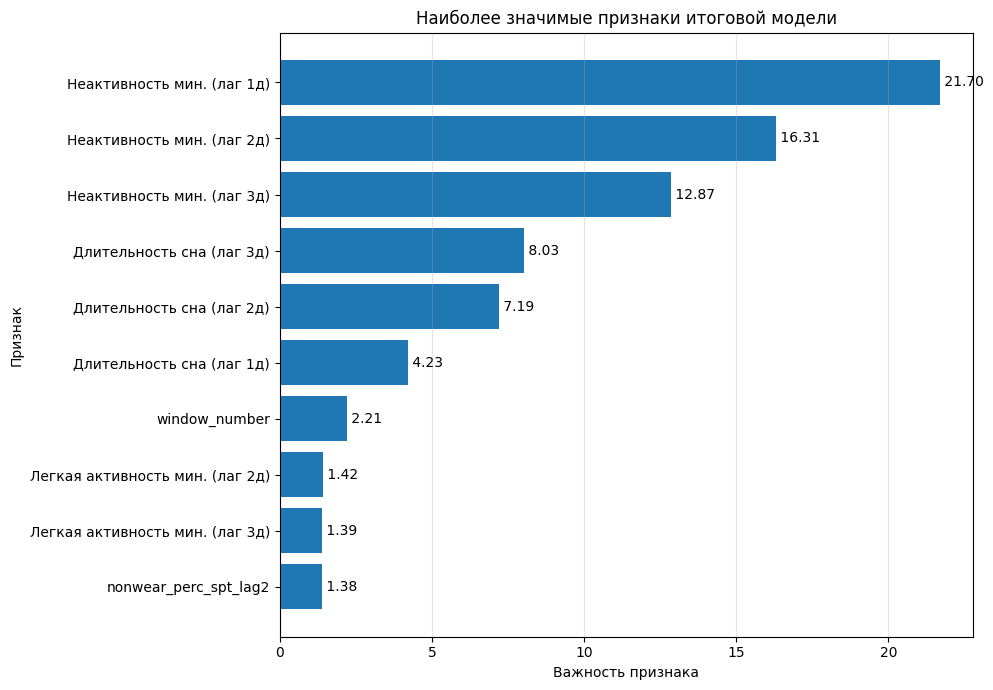

In [46]:
top_n = 10
plot_df = importance_df.head(top_n).copy()

# если не нужна русификация, замени feature_ru на feature
label_col = "feature_ru" if "feature_ru" in plot_df.columns else "feature"

plot_df = plot_df.sort_values("importance", ascending=True)

plt.figure(figsize=(10, 7))
bars = plt.barh(plot_df[label_col], plot_df["importance"])

plt.title("Наиболее значимые признаки итоговой модели")
plt.xlabel("Важность признака")
plt.ylabel("Признак")
plt.grid(axis="x", alpha=0.3)

for bar, value in zip(bars, plot_df["importance"]):
    plt.text(
        value,
        bar.get_y() + bar.get_height() / 2,
        f" {value:.2f}",
        va="center"
    )

plt.tight_layout()
plt.savefig(FIG_DIR / "figure_3_6_feature_importance_final_model.png", dpi=300, bbox_inches="tight")
plt.show()

In [47]:
from catboost import CatBoostClassifier, Pool
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

final_model_path = MODELS_DIR / "catboost_tuned_no_sleep_quality_lag.cbm"

X_test_final_model = select_feature_set(X_test_full, "no_sleep_quality_lag").copy()

categorical_cols = X_test_final_model.select_dtypes(include=["object"]).columns.tolist()
cat_features = [X_test_final_model.columns.get_loc(col) for col in categorical_cols]

test_pool_final = Pool(
    X_test_final_model,
    y_test,
    cat_features=cat_features
)

final_model = CatBoostClassifier()
final_model.load_model(str(final_model_path))

y_test_proba_final = final_model.predict_proba(test_pool_final)[:, 1]

print("Размер тестовой выборки:", len(y_test))
print("Диапазон вероятностей:", y_test_proba_final.min(), y_test_proba_final.max())

Размер тестовой выборки: 9547
Диапазон вероятностей: 0.03564901438410267 0.9253235710734391


In [48]:
plot_pred_df = pd.DataFrame({
    "y_true": y_test.values,
    "y_proba": y_test_proba_final
})

plot_pred_df["class_name"] = plot_pred_df["y_true"].map({
    0: "0 — благоприятный сон",
    1: "1 — неблагоприятный сон"
})

plot_pred_df.head()

,y_true,y_proba,class_name
0,1,0.496636,1 — неблагоприятный сон
1,1,0.705325,1 — неблагоприятный сон
2,1,0.700589,1 — неблагоприятный сон
3,1,0.740043,1 — неблагоприятный сон
4,0,0.245180,0 — благоприятный сон


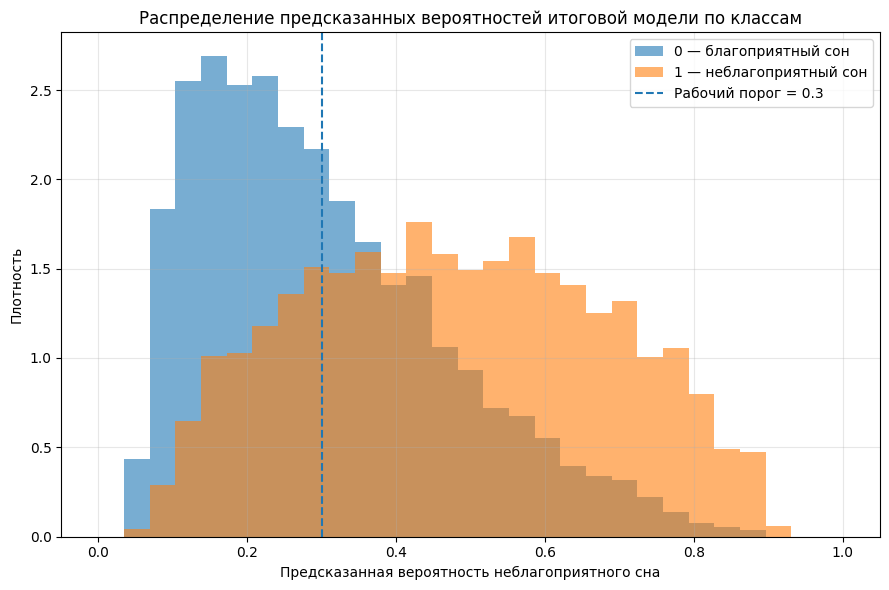

In [49]:
plt.figure(figsize=(9, 6))

bins = np.linspace(0, 1, 30)

plt.hist(
    plot_pred_df.loc[plot_pred_df["y_true"] == 0, "y_proba"],
    bins=bins,
    alpha=0.6,
    density=True,
    label="0 — благоприятный сон"
)

plt.hist(
    plot_pred_df.loc[plot_pred_df["y_true"] == 1, "y_proba"],
    bins=bins,
    alpha=0.6,
    density=True,
    label="1 — неблагоприятный сон"
)

plt.axvline(x=0.3, linestyle="--", linewidth=1.5, label="Рабочий порог = 0.3")

plt.title("Распределение предсказанных вероятностей итоговой модели по классам")
plt.xlabel("Предсказанная вероятность неблагоприятного сна")
plt.ylabel("Плотность")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / "figure_3_7_probability_distribution_by_class.png", dpi=300, bbox_inches="tight")
plt.show()